In [91]:
import numpy as np # type: ignore
import cv2 # type: ignore
import matplotlib.pyplot as plt # type: ignore

# Entrenamiento de una red de Hopfield con imágenes binarias

Cargo las imagenes y pruebo llevarlas a todas a una misma resolución

In [92]:
#Imagenes de 2500 pixeles (50x50)
pandaOriginal = cv2.imread("panda.bmp", cv2.IMREAD_GRAYSCALE)
vOriginal = cv2.imread("v.bmp", cv2.IMREAD_GRAYSCALE)
perroOriginal = cv2.imread("perro.bmp", cv2.IMREAD_GRAYSCALE)

#Imagenes de 2925 pixeles (65x45)
quijoteOriginal = cv2.imread("quijote.bmp", cv2.IMREAD_GRAYSCALE)
palomaOriginal = cv2.imread("paloma.bmp", cv2.IMREAD_GRAYSCALE)
toreroOriginal = cv2.imread("torero.bmp", cv2.IMREAD_GRAYSCALE)


Para entrenar a la red neuronal o evaluarla, necesito a las imagenes en forma de vector y en el caso del entrenamiento cada imagen va a ser la columna de una matriz

In [93]:
def load_image_to_pattern(image):
    _, binary_image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY) # Convertir la imagen binaria a valores 0 y 1
    patron = (binary_image / 255.0) * 2 - 1 # Convertir la imagen binaria a valores -1 y 1
    return patron.flatten() # Me devuelve un arreglo unidimensional

In [94]:
def recover_image(imageVectorized, originalShape = (50,50)):
    # Reconvertir el estado 1D a la forma original de la imagen
    recoveredImage = imageVectorized.reshape(originalShape)
    
    # Convertir de valores -1, 1 a 0, 255 para poder visualizar como imagen
    recoveredImage = (recoveredImage + 1) / 2 * 255
    return recoveredImage.astype(np.uint8)

# Ejercicio 1
Entrene una red de Hopfield '82 con las imágenes binarias disponibles en el campus.

1. **Verifique** si la red aprendió las imágenes enseñadas.
2. **Evalúe la evolución** de la red al presentarle versiones alteradas de las imágenes aprendidas:
   - Agregado de ruido,
   - Elementos borrados o agregados.
3. **Evalúe la existencia** de estados espurios en la red:
   - Patrones inversos,
   - Combinaciones de un número impar de patrones.
   
   *(Ver "Spurious States", en la sección 2.2, Hertz, Krogh & Palmer, pág. 24)*.
   
4. **Realice un entrenamiento** con las 6 imágenes disponibles. ¿Es capaz la red de aprender todas las imágenes? Explique.

Se utilizara la siguiente implementación de la Red Hopfield

In [95]:
class HopfieldNetwork:
    def __init__(self, num_neurons):
        self.num_neurons = num_neurons
        self.weights = np.zeros((num_neurons, num_neurons))


    def train(self, patterns):
        self.weights += patterns @ patterns.T
        np.fill_diagonal(self.weights, 0)
    

    def evaluate_asynchronous(self, inicialInput):
        state = inicialInput
        previousState= np.zeros((self.num_neurons, 1))
        cicles = 0
        while not (np.array_equal(state, previousState)):
            previousState = state
            indices = np.random.permutation(self.num_neurons)
            for i in indices :
                sum = np.dot(self.weights[i,:], state)
                state[i] = np.where(sum > 0,1,-1)               
            cicles += 1 
        return state,cicles
    
    
    def evaluate_synchronous(self, pattern):
        sum_values = self.weights @ pattern
        return np.where(sum_values > 0,1,-1) 
    

### Red Hopfield para tamaño 50x50 : *Red1*


La red Hopfield **red1** trabajara solo con las imagenes de tamaño 50x50:  *panda.bmp*, *perro.bmp* y *v.bmp*

In [96]:
patterns1 = []
patterns1.append(load_image_to_pattern(pandaOriginal))
patterns1.append(load_image_to_pattern(vOriginal))
patterns1.append(load_image_to_pattern(perroOriginal))
patterns1 = np.array(patterns1).T

red1 = HopfieldNetwork(2500)
red1.train(patterns1)

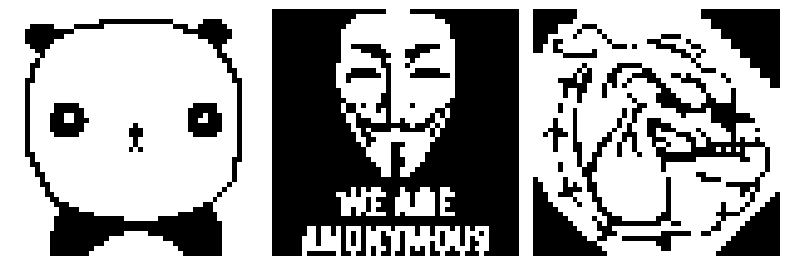

In [97]:
fig, axes = plt.subplots(1, 3, figsize =(8,5))  

axes[0].imshow(pandaOriginal, cmap='gray')
axes[0].axis('off') 

axes[1].imshow(vOriginal, cmap='gray')
axes[1].axis('off')  

axes[2].imshow(perroOriginal, cmap='gray')
axes[2].axis('off')  

plt.tight_layout()
plt.show()

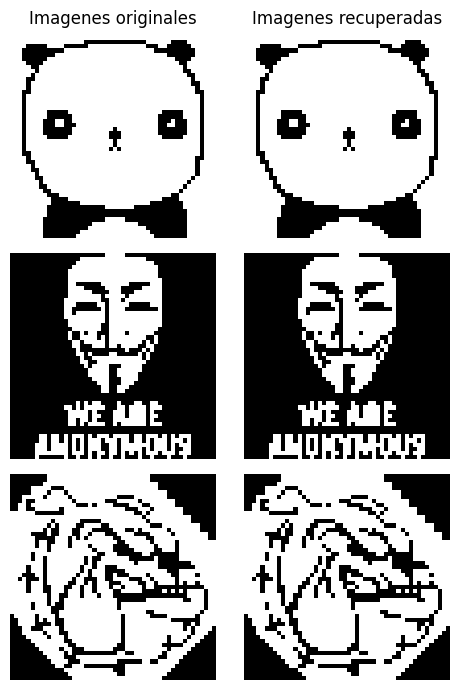

In [98]:
recovered = []
original_images = [pandaOriginal, vOriginal, perroOriginal]

for i in original_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  


fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(original_images[i], cmap='gray')
    axes[i, 0].axis('off')  # Ocultar los ejes
    axes[0, 0].set_title(f"Imagenes originales")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  # Ocultar los ejes
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

Se evaluara la red con imagenes recortadas para ver si logra recuperarlas

In [99]:
import random
def crop_image(image, crop_percentage):
    # Determino el tamaño del recorte
    height, width = image.shape[:2]
    crop_height = int(height * crop_percentage)
    crop_width = int(width * crop_percentage)

    # Elijo de forma aleatoria si recortar horizontal o verticalmente
    if random.choice(['horizontal', 'vertical']) == 'horizontal':
        # Recorte horizontal
        start_row = random.randint(0, height - crop_height)
        image[start_row:start_row + crop_height, :] = 255 
    else:
        # Recorte vertical
        start_col = random.randint(0, width - crop_width)
        image[:, start_col:start_col + crop_width] = 255 

    return image



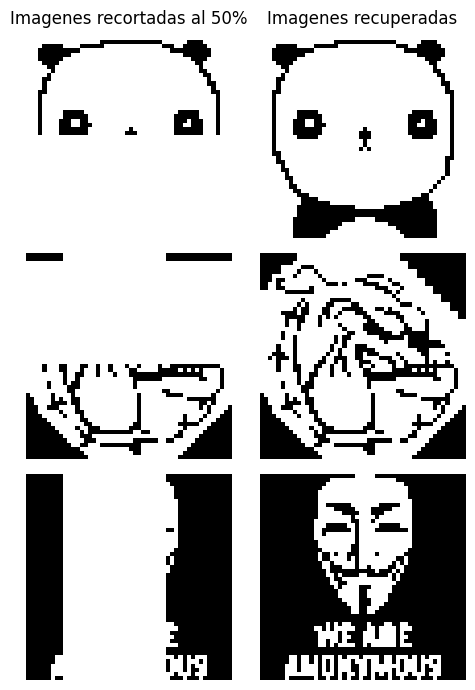

In [100]:
pandaRecortado = crop_image(pandaOriginal.copy(), crop_percentage=0.5)  # 50% de recorte
perroRecortado = crop_image(perroOriginal.copy(), crop_percentage=0.5)
vRecortado = crop_image(vOriginal.copy(), crop_percentage=0.5)

cut_images = [pandaRecortado, perroRecortado, vRecortado]

recovered_images = []
for image in cut_images:
    example, cycles = red1.evaluate_asynchronous(load_image_to_pattern(image))
    recovered_images.append(recover_image(example, (50, 50)))

fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(cut_images[i], cmap='gray')
    axes[i, 0].axis('off') 
    axes[0, 0].set_title(f"Imagenes recortadas al 50%")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered_images[i], cmap='gray')
    axes[i, 1].axis('off') 
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

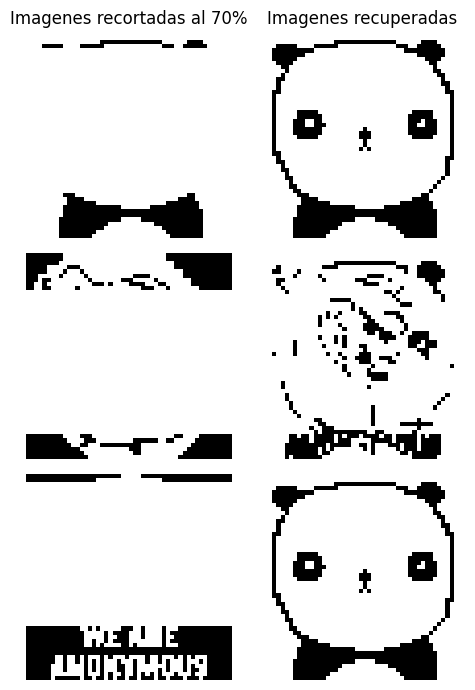

In [101]:
pandaRecortado = crop_image(pandaOriginal.copy(), crop_percentage=0.7)  # 70% de recorte
perroRecortado = crop_image(perroOriginal.copy(), crop_percentage=0.7)
vRecortado = crop_image(vOriginal.copy(), crop_percentage=0.7)

cut_images = [pandaRecortado, perroRecortado, vRecortado]

recovered_images = []
for image in cut_images:
    example, cycles = red1.evaluate_asynchronous(load_image_to_pattern(image))
    recovered_images.append(recover_image(example, (50, 50)))

fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(cut_images[i], cmap='gray')
    axes[i, 0].axis('off') 
    axes[0, 0].set_title(f"Imagenes recortadas al 70%")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered_images[i], cmap='gray')
    axes[i, 1].axis('off') 
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

Se evaluara la red con imagenes con ruido para ver si logra recuperarlas

In [102]:
import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt

def get_noisy_image(input_image, porcentaje, color_borrar=255):
    output_image = input_image.copy()

    # Obtengo dimensiones de la imagen
    height, width = output_image.shape
    total_pixeles = width * height

    # Calculo cuántos píxeles debemos borrar
    pixeles_a_borrar = int(total_pixeles * (porcentaje / 100))

    # Creo una lista de todas las coordenadas de la imagen
    coordenadas = [(x, y) for x in range(width) for y in range(height)]

    # Selecciono al azar las coordenadas a borrar
    coordenadas_borrar = random.sample(coordenadas, pixeles_a_borrar)

    # Borro los píxeles (los cambio al color especificado)
    for coord in coordenadas_borrar:
        output_image[coord[1], coord[0]] = color_borrar 

    return output_image 


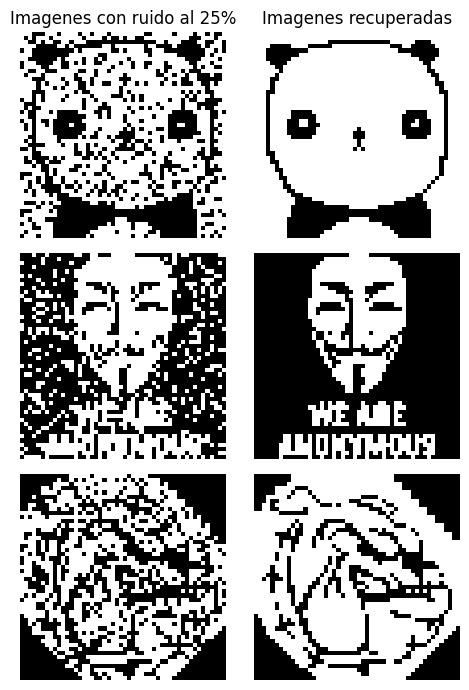

In [103]:
pandaRuidoso25 = get_noisy_image(pandaOriginal, 25, 0)   # 25% de ruido
vRuidoso25 = get_noisy_image(vOriginal, 25, 255)
perroRuidoso25 = get_noisy_image(perroOriginal, 25, 0)

noisy_images = [pandaRuidoso25, vRuidoso25, perroRuidoso25]

recovered = []
for i in noisy_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  

fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(noisy_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagenes con ruido al 25%")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

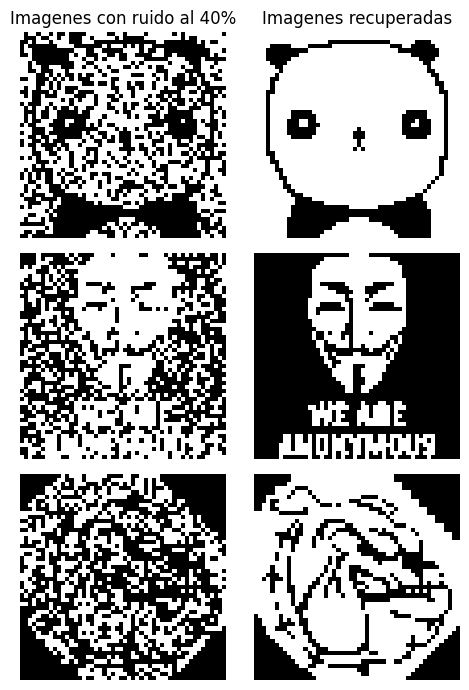

In [104]:
pandaRuidoso40 = get_noisy_image(pandaOriginal, 40, 0)  # 40% de ruido
vRuidoso40 = get_noisy_image(vOriginal, 40, 255)
perroRuidoso40 = get_noisy_image(perroOriginal, 40, 0)

noisy_images = [pandaRuidoso40, vRuidoso40, perroRuidoso40]

recovered = []
for i in noisy_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  

fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(noisy_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagenes con ruido al 40%")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

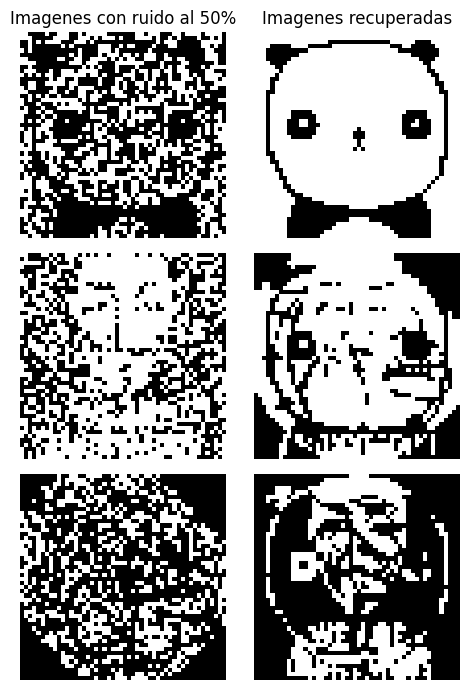

In [105]:
pandaRuidoso50 = get_noisy_image(pandaOriginal, 50, 0)  #50% de ruido
vRuidoso50 = get_noisy_image(vOriginal, 50, 255)
perroRuidoso50 = get_noisy_image(perroOriginal, 50, 0)

noisy_images = [pandaRuidoso50, vRuidoso50, perroRuidoso50]

recovered = []
for i in noisy_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  

fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(noisy_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagenes con ruido al 50%")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

Busco estados espureos, es decir combinaciones impares de patrones que pudo haber aprendido la red

In [106]:
espureo1 = -1*load_image_to_pattern(pandaOriginal.copy())
espureo2 = -1*load_image_to_pattern(vOriginal.copy())
espureo3 = -1*load_image_to_pattern(perroOriginal.copy())
espureo4 = np.where( load_image_to_pattern(pandaOriginal.copy()) + load_image_to_pattern(vOriginal.copy()) + load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo5 = np.where( -load_image_to_pattern(pandaOriginal.copy()) + load_image_to_pattern(vOriginal.copy()) + load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo6 = np.where( -load_image_to_pattern(pandaOriginal.copy()) - load_image_to_pattern(vOriginal.copy()) + load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo7 = np.where( -load_image_to_pattern(pandaOriginal.copy()) - load_image_to_pattern(vOriginal.copy()) - load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo8 = np.where( load_image_to_pattern(pandaOriginal.copy()) - load_image_to_pattern(vOriginal.copy()) - load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo9 = np.where( load_image_to_pattern(pandaOriginal.copy()) + load_image_to_pattern(vOriginal.copy()) - load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)

espureo10 = np.where( -load_image_to_pattern(pandaOriginal.copy()) + load_image_to_pattern(vOriginal.copy()) - load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo11 = -1 * espureo8



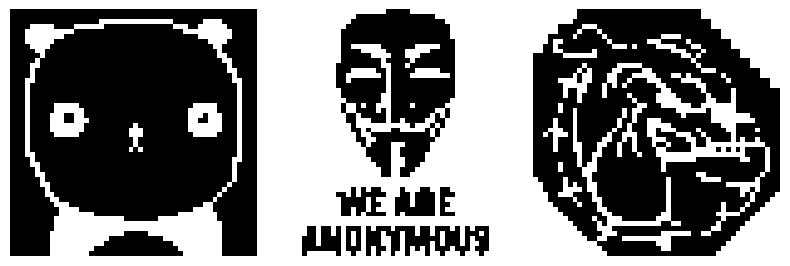

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(8, 8))  # 2 filas y 3 columnas

combined_images = [recover_image(espureo1), recover_image(espureo2), recover_image(espureo3)] 

for i in range(3):
    # Muestro imágenes con ruido (primer fila)
    axes[i].imshow(combined_images[i], cmap='gray')
    axes[i].axis('off')  

plt.tight_layout()
plt.show()

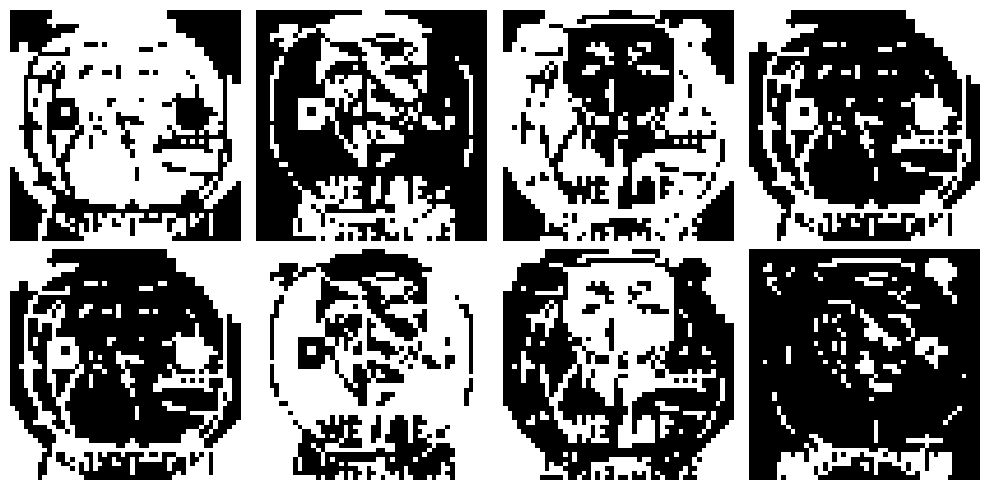

In [108]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))  # 2 filas y 4 columnas

combined_images = [recover_image(espureo4), recover_image(espureo5), recover_image(espureo6), recover_image(espureo7), 
                   recover_image(espureo8), recover_image(espureo9), recover_image(espureo10), recover_image(espureo11)] 

for i in range(4):
    # Muestro imágenes con ruido (primer fila)
    axes[0, i].imshow(combined_images[i], cmap='gray')
    axes[0, i].axis('off') 

    # Muestro imágenes recuperadas (segunda fila)
    axes[1, i].imshow(combined_images[i + 3], cmap='gray')
    axes[1, i].axis('off') 


plt.tight_layout()
plt.show()

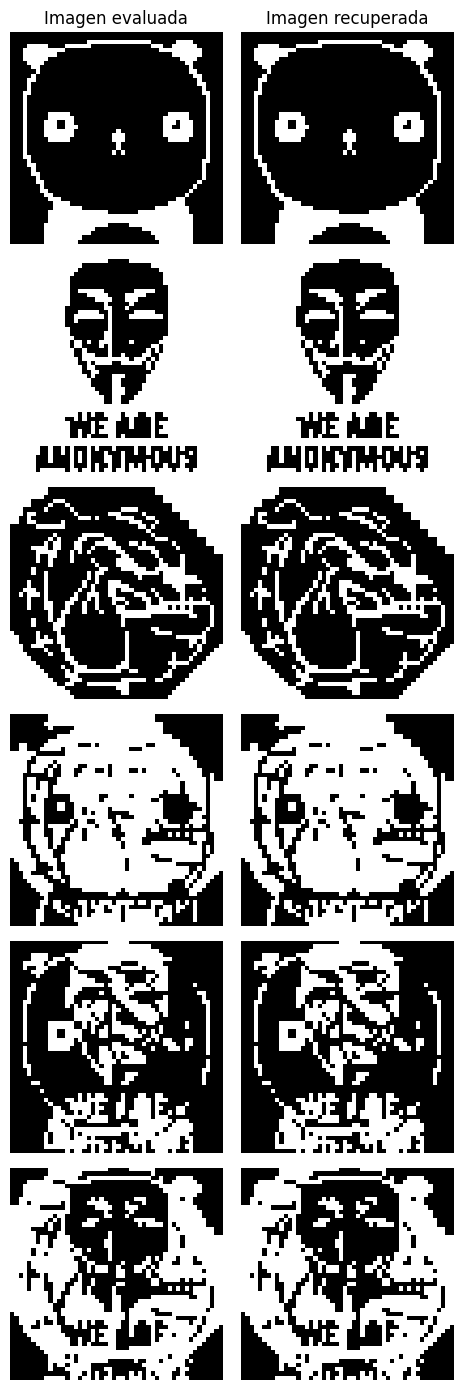

In [109]:
espurio_images = [recover_image(espureo1), recover_image(espureo2), recover_image(espureo3),
                  recover_image(espureo4), recover_image(espureo5), recover_image(espureo6), recover_image(espureo7), 
                  recover_image(espureo8), recover_image(espureo9), recover_image(espureo10), recover_image(espureo11)]

recovered = []
for i in espurio_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  


fig, axes = plt.subplots(6, 2, figsize=(5, 14))  # 6 filas y 2 columnas
for i in range(6):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(espurio_images[i], cmap='gray')
    axes[i, 0].axis('off') 
    axes[0, 0].set_title(f"Imagen evaluada")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off') 
    axes[0, 1].set_title(f"Imagen recuperada")

plt.tight_layout()
plt.show()

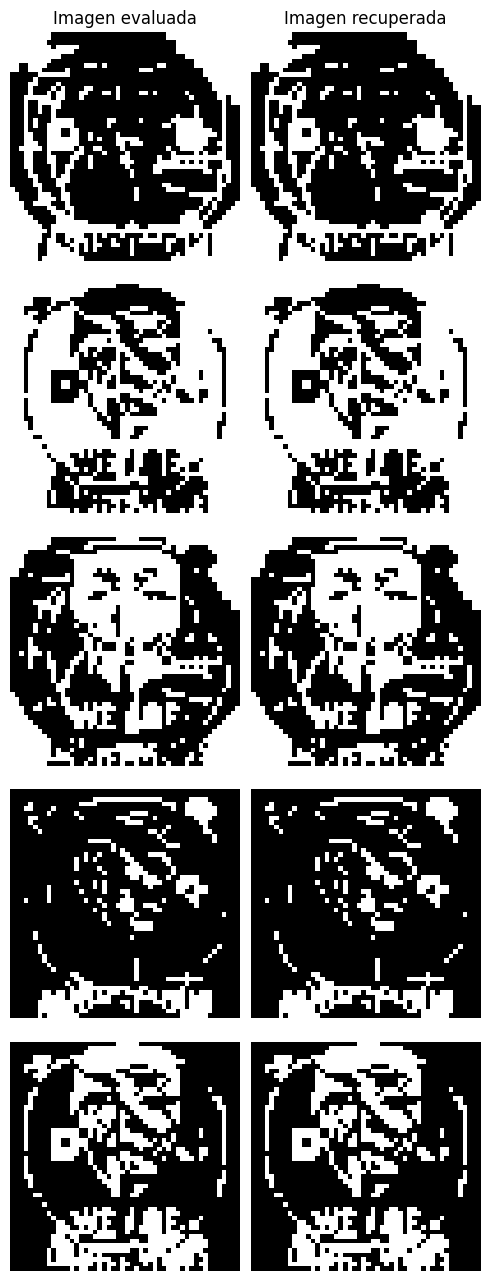

In [110]:
espurio_images = [recover_image(espureo7), recover_image(espureo8), recover_image(espureo9), recover_image(espureo10), recover_image(espureo11)]

recovered = []
for i in espurio_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  


fig, axes = plt.subplots(5, 2, figsize=(5, 13))  # 5 filas y 2 columnas
for i in range(5):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(espurio_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagen evaluada")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagen recuperada")

plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Red Hopfield para tamaño 45x60 : *Red2*

Pruebo red neuronal para el caso de completar los pixeles faltantes de las imagenes

In [111]:
patterns2 = []
patterns2.append(load_image_to_pattern(palomaOriginal))
patterns2.append(load_image_to_pattern(quijoteOriginal))
patterns2.append(load_image_to_pattern(toreroOriginal))
patterns2 = np.array(patterns2).T

red2 = HopfieldNetwork(2700)
red2.train(patterns2)

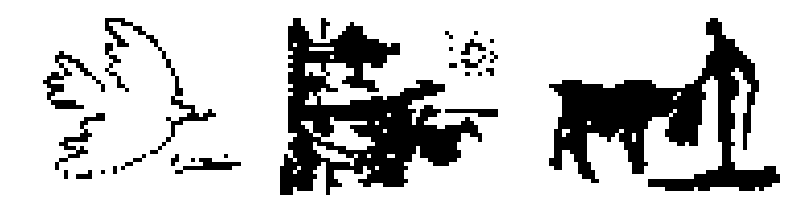

In [112]:
fig, axes = plt.subplots(1, 3, figsize =(8,5))  

axes[0].imshow(palomaOriginal, cmap='gray')
axes[0].axis('off') 

axes[1].imshow(quijoteOriginal, cmap='gray')
axes[1].axis('off')  

axes[2].imshow(toreroOriginal, cmap='gray')
axes[2].axis('off')  

plt.tight_layout()
plt.show()

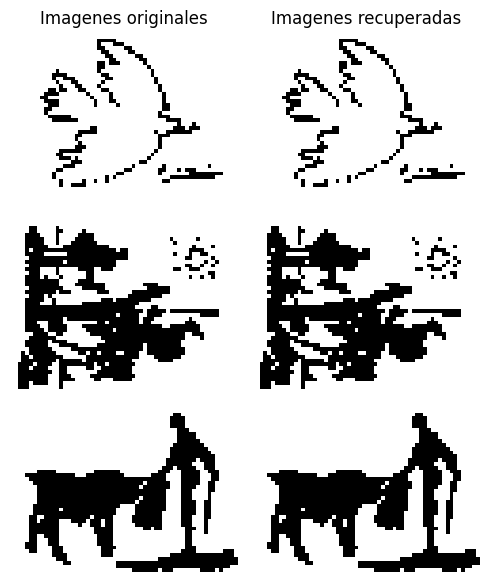

In [113]:
recovered = []
original_images = [palomaOriginal, quijoteOriginal, toreroOriginal]

for i in original_images:
    example,_ = red2.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (45,60)))  


fig, axes = plt.subplots(3, 2, figsize=(5, 6))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(original_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagenes originales")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

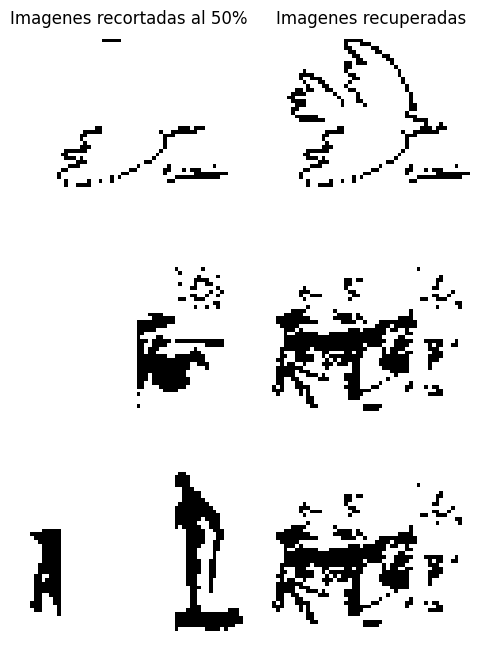

In [114]:
palomaRecortado = crop_image(palomaOriginal.copy(), crop_percentage=0.5)  # 50% de recorte
quijoteRecortado = crop_image(quijoteOriginal.copy(), crop_percentage=0.5)
toreroRecortado = crop_image(toreroOriginal.copy(), crop_percentage=0.5)

cut_images = [palomaRecortado, quijoteRecortado, toreroRecortado]

recovered_images = []
for image in cut_images:
    example, cycles = red2.evaluate_asynchronous(load_image_to_pattern(image))
    recovered_images.append(recover_image(example, (45, 60)))


fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(cut_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagenes recortadas al 50%")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered_images[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

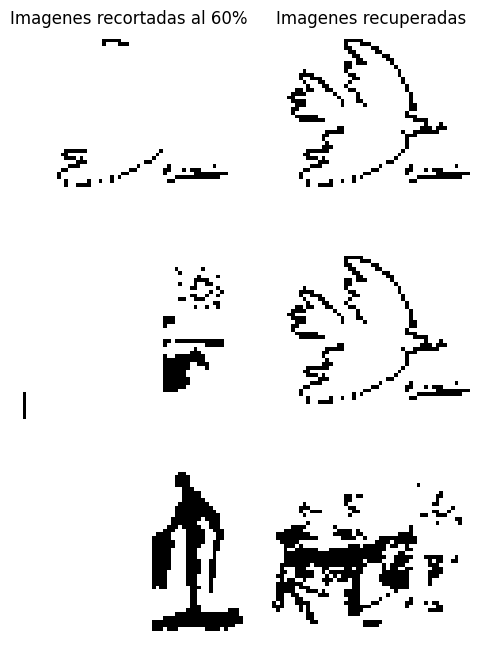

In [115]:
palomaRecortado = crop_image(palomaOriginal.copy(), crop_percentage=0.6)  # 60% de recorte
quijoteRecortado = crop_image(quijoteOriginal.copy(), crop_percentage=0.6)
toreroRecortado = crop_image(toreroOriginal.copy(), crop_percentage=0.6)

cut_images = [palomaRecortado, quijoteRecortado, toreroRecortado]

recovered_images = []
for image in cut_images:
    example, cycles = red2.evaluate_asynchronous(load_image_to_pattern(image))
    recovered_images.append(recover_image(example, (45, 60)))

fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(cut_images[i], cmap='gray')
    axes[i, 0].axis('off') 
    axes[0, 0].set_title(f"Imagenes recortadas al 60%")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered_images[i], cmap='gray')
    axes[i, 1].axis('off') 
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

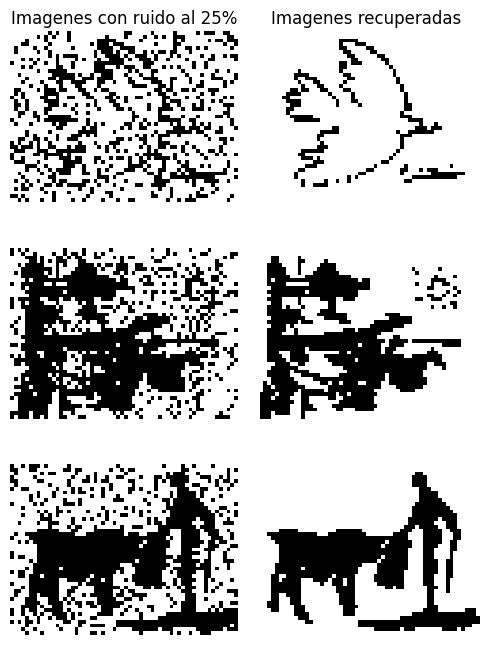

In [116]:
palomaRuidoso25 = get_noisy_image(palomaOriginal, 25, 0)  
quijoteRuidoso25 = get_noisy_image(quijoteOriginal, 25, 0)
toreroRuidoso25 = get_noisy_image(toreroOriginal, 25, 0)

noisy_images = [palomaRuidoso25, quijoteRuidoso25, toreroRuidoso25]

recovered = []
for i in noisy_images:
    example,_ = red2.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (45,60)))  


fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(noisy_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagenes con ruido al 25%")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

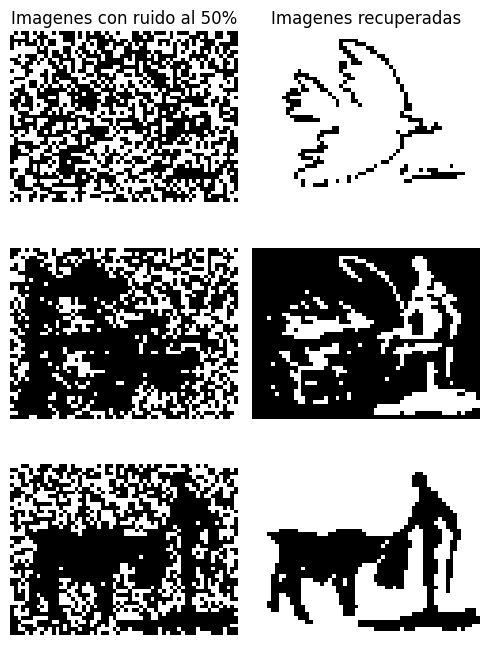

In [117]:
palomaRuidoso50 = get_noisy_image(palomaOriginal, 50, 0)  
quijoteRuidoso50 = get_noisy_image(quijoteOriginal, 50, 0)
toreroRuidoso50 = get_noisy_image(toreroOriginal, 50, 0)

noisy_images = [palomaRuidoso50, quijoteRuidoso50, toreroRuidoso50]

recovered = []
for i in noisy_images:
    example,_ = red2.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (45,60)))  

fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(noisy_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagenes con ruido al 50%")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

In [118]:
espureo1 = -1*load_image_to_pattern(palomaOriginal.copy())
espureo2 = -1*load_image_to_pattern(quijoteOriginal.copy())
espureo3 = -1*load_image_to_pattern(toreroOriginal.copy())
espureo4 = np.where( load_image_to_pattern(palomaOriginal.copy()) + load_image_to_pattern(quijoteOriginal.copy()) + load_image_to_pattern(toreroOriginal.copy())  > 0,1,-1)
espureo5 = np.where( -load_image_to_pattern(palomaOriginal.copy()) + load_image_to_pattern(quijoteOriginal.copy()) + load_image_to_pattern(toreroOriginal.copy())  > 0,1,-1)
espureo6 = np.where( -load_image_to_pattern(palomaOriginal.copy()) - load_image_to_pattern(quijoteOriginal.copy()) + load_image_to_pattern(toreroOriginal.copy())  > 0,1,-1)
espureo7 = np.where( -load_image_to_pattern(palomaOriginal.copy()) - load_image_to_pattern(quijoteOriginal.copy()) - load_image_to_pattern(toreroOriginal.copy())  > 0,1,-1)
espureo8 = np.where( load_image_to_pattern(palomaOriginal.copy()) - load_image_to_pattern(quijoteOriginal.copy()) - load_image_to_pattern(toreroOriginal.copy())  > 0,1,-1)
espureo9 = np.where( load_image_to_pattern(palomaOriginal.copy()) + load_image_to_pattern(quijoteOriginal.copy()) - load_image_to_pattern(toreroOriginal.copy())  > 0,1,-1)

espureo10 = np.where( -load_image_to_pattern(palomaOriginal.copy()) + load_image_to_pattern(quijoteOriginal.copy()) - load_image_to_pattern(toreroOriginal.copy())  > 0,1,-1)
espureo11 = -1 * espureo8

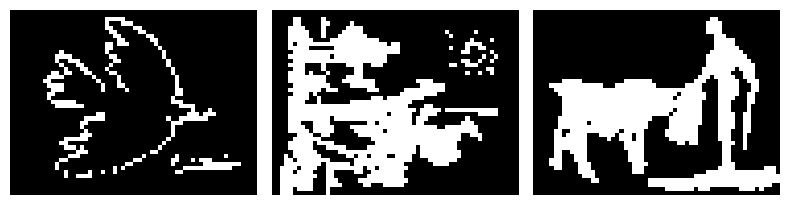

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(8, 8))  # 1 filas y 3 columnas

combined_images = [recover_image(espureo1,(45,60)), recover_image(espureo2,(45,60)), recover_image(espureo3,(45,60))] 

for i in range(3):
    axes[i].imshow(combined_images[i], cmap='gray')
    axes[i].axis('off') 

plt.tight_layout()
plt.show()

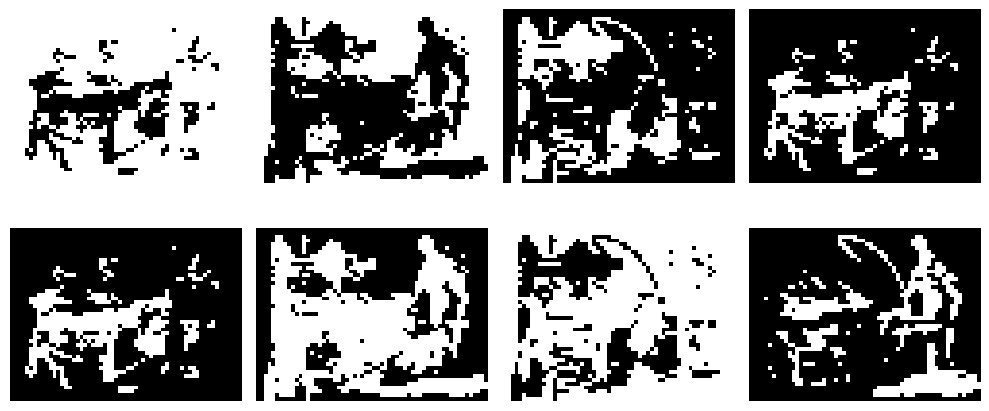

In [120]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))  # 2 filas y 4 columnas
combined_images = [recover_image(espureo4,(45,60)), recover_image(espureo5,(45,60)), recover_image(espureo6,(45,60)), recover_image(espureo7,(45,60)), 
                   recover_image(espureo8,(45,60)), recover_image(espureo9,(45,60)), recover_image(espureo10,(45,60)), recover_image(espureo11,(45,60))] # Lista combinada

for i in range(4):
    # Muestro imágenes con ruido (primer fila)
    axes[0, i].imshow(combined_images[i], cmap='gray')
    axes[0, i].axis('off')  

    # Muestro imágenes recuperadas (segunda fila)
    axes[1, i].imshow(combined_images[i + 3], cmap='gray')
    axes[1, i].axis('off') 


plt.tight_layout()
plt.show()

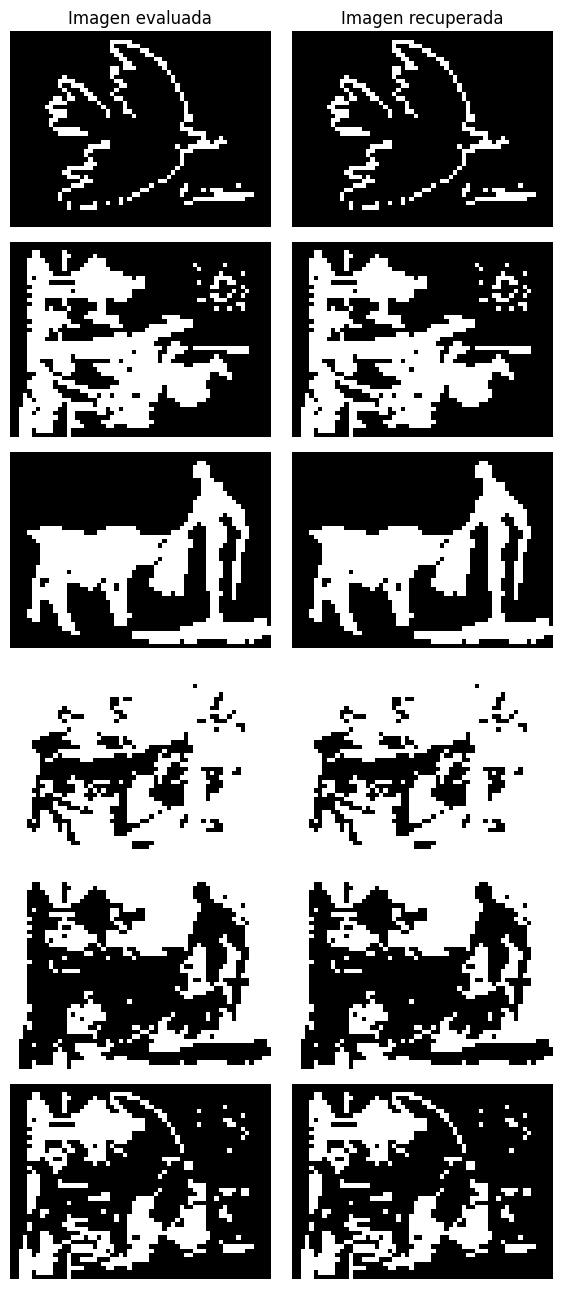

In [121]:
espurio_images = [recover_image(espureo1,(45,60)), recover_image(espureo2,(45,60)), recover_image(espureo3,(45,60)),
                  recover_image(espureo4,(45,60)), recover_image(espureo5,(45,60)), recover_image(espureo6,(45,60)), recover_image(espureo7,(45,60)), 
                  recover_image(espureo8,(45,60)), recover_image(espureo9,(45,60)), recover_image(espureo10,(45,60)), recover_image(espureo11,(45,60))]

recovered = []
for i in espurio_images:
    example,_ = red2.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (45,60)))  


fig, axes = plt.subplots(6, 2, figsize=(6, 13))  # 6 filas y 2 columnas
for i in range(6):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(espurio_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagen evaluada")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagen recuperada")

plt.tight_layout()
plt.show()

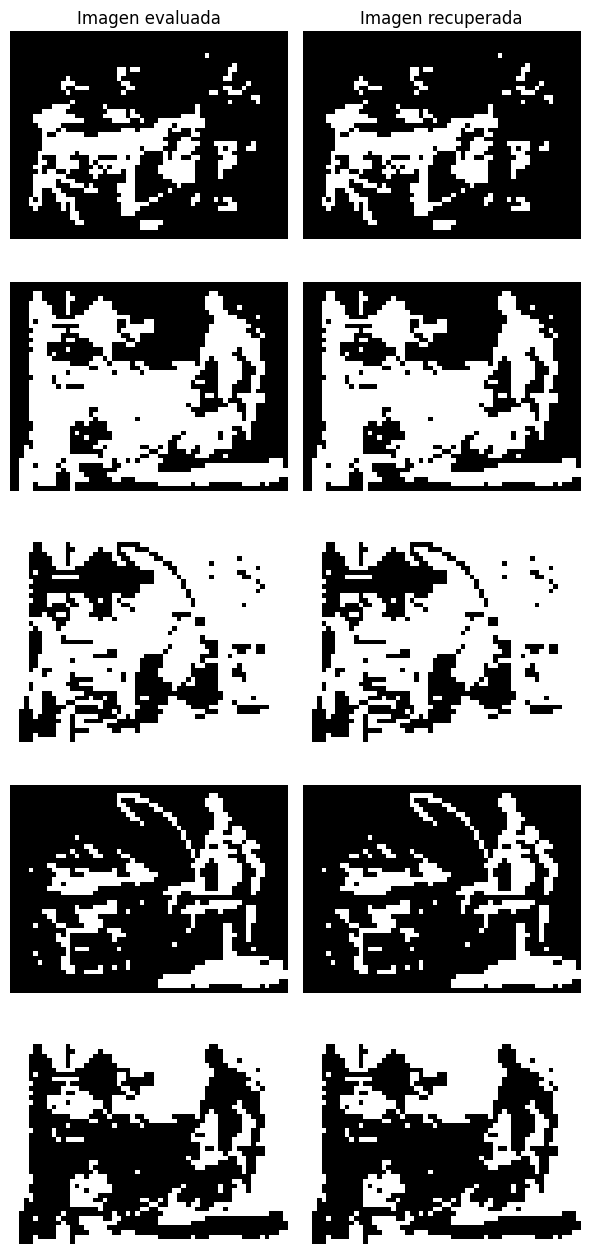

In [122]:
espurio_images = [recover_image(espureo7,(45,60)), recover_image(espureo8,(45,60)), recover_image(espureo9,(45,60)), recover_image(espureo10,(45,60)), recover_image(espureo11,(45,60))]

recovered = []
for i in espurio_images:
    example,_ = red2.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example,(45,60)))  


fig, axes = plt.subplots(5, 2, figsize=(6, 13))  # 5 filas y 2 columnas
for i in range(5):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(espurio_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagen evaluada")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagen recuperada")

plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Red Hopfield con imagenes redimensionadas : *Red3*

Ahora pruebo una red neuronal con imagenes escaladas

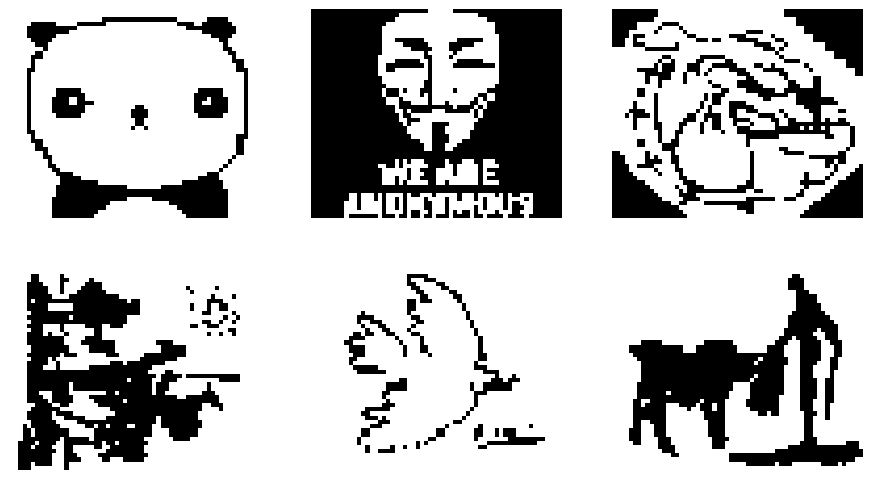

In [123]:
scale = (60,50)
pandaScaled = cv2.resize(pandaOriginal, scale, interpolation=cv2.INTER_NEAREST)
vScaled = cv2.resize(vOriginal, scale, interpolation=cv2.INTER_NEAREST)
perroScaled = cv2.resize(perroOriginal, scale, interpolation=cv2.INTER_NEAREST)
quijoteScaled = cv2.resize(quijoteOriginal, scale, interpolation=cv2.INTER_NEAREST)
palomaScaled = cv2.resize(palomaOriginal, scale, interpolation=cv2.INTER_NEAREST)
toreroScaled = cv2.resize(toreroOriginal, scale, interpolation=cv2.INTER_NEAREST)

scaled_images = [pandaScaled, vScaled, perroScaled, quijoteScaled, palomaScaled, toreroScaled]
fig, axes = plt.subplots(2, 3, figsize=(11, 6))  # 2 filas y 3 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[0, i].imshow(scaled_images[i], cmap='gray')
    axes[0, i].axis('off')  

    
    # Muestro imágenes recuperadas (columna derecha)
    axes[1, i].imshow(scaled_images[i+3], cmap='gray')
    axes[1, i].axis('off')  


In [124]:
patterns3 = []
patterns3.append(load_image_to_pattern(pandaScaled))
patterns3.append(load_image_to_pattern(vScaled))
patterns3.append(load_image_to_pattern(perroScaled))
patterns3.append(load_image_to_pattern(palomaScaled))
patterns3.append(load_image_to_pattern(toreroScaled))
patterns3.append(load_image_to_pattern(quijoteScaled))
patterns3 = np.array(patterns3).T

red3 = HopfieldNetwork(3000)
red3.train(patterns3)

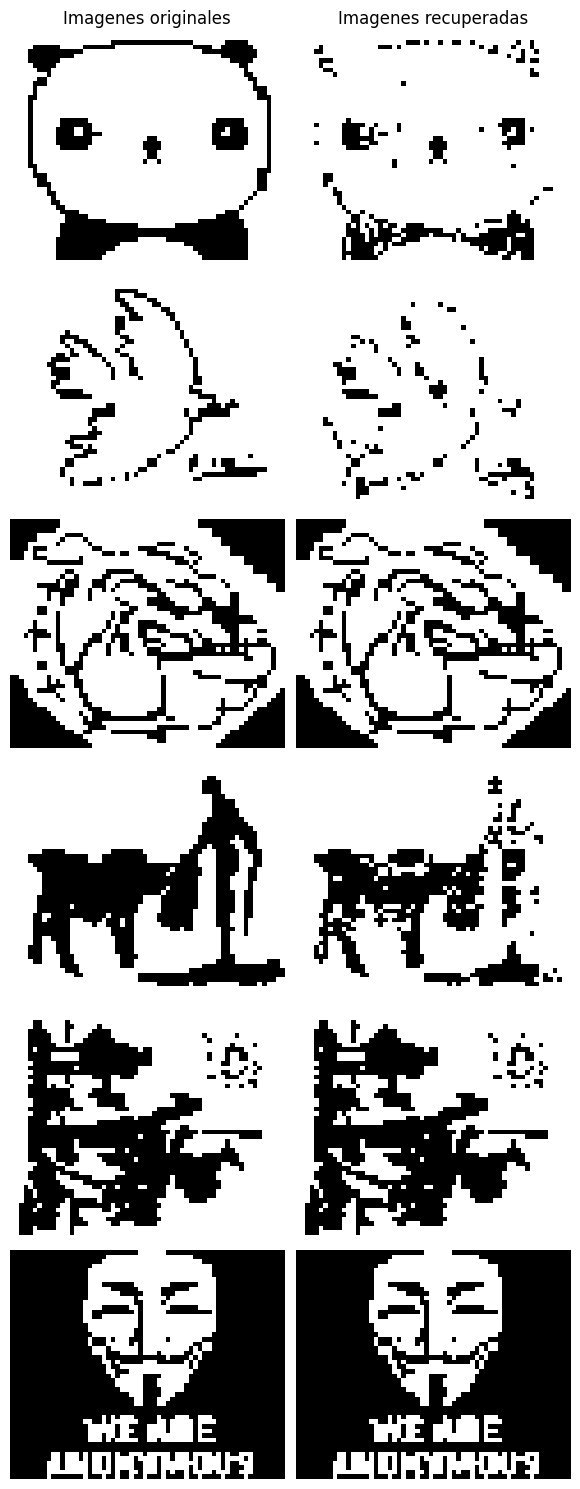

In [125]:
recovered = []

original_images = [pandaScaled, palomaScaled, perroScaled, toreroScaled, quijoteScaled, vScaled]

for i in original_images:
    example,_ = red3.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,60)))


fig, axes = plt.subplots(6, 2, figsize=(6, 15))  # 6 filas y 2 columnas
for i in range(6):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(original_images[i], cmap='gray')
    axes[i, 0].axis('off')  
    axes[0, 0].set_title(f"Imagenes originales")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

### Ejercicio 2

a) Comprobar estadísticamente la capacidad de la red de Hopfield '82 calculando la cantidad máxima de patrones pseudo-aleatorios aprendidos en función del tamaño de la red. Obtener experimentalmente los resultados de la siguiente tabla (los valores de la tabla corresponden a una iteración con actualización sincrónica).

| P_error | p_max/N |
|---------|---------|
| 0,001   | 0,105   |
| 0,0036  | 0,138   |
| 0,01    | 0,185   |
| 0,05    | 0,37    |
| 0,1     | 0,61    |

_(Tabla 2.1, sección 2.2, Hertz, Krogh & Palmer, pág. 19)_

b) Proponga una manera de generar patrones con distintos grados de correlación. Utilice el método propuesto para analizar cómo varía la capacidad de la red de Hopfield en función de la correlación entre patrones.


In [126]:
def capacity_by_error(P_error, N):
    hopfield_net = HopfieldNetwork(N)
    patterns_accumulated = np.empty((N, 0)) 
    error_neurons = 0
    
    while error_neurons < P_error:
        new_pattern = np.random.choice([-1, 1], size=(N,)).reshape(N, 1)  # Genera una columna
        hopfield_net.train(new_pattern)  # Entrenamos con el patrón como vector unidimensional
        patterns_accumulated = np.hstack((patterns_accumulated, new_pattern))
        evaluated_patterns = hopfield_net.evaluate_synchronous(patterns_accumulated)
        error_neurons = np.count_nonzero(evaluated_patterns- patterns_accumulated) / (patterns_accumulated.shape[1]*N)
        
    capacity = (patterns_accumulated.shape[1]-1)/N
    return capacity


In [127]:
capacities = []
aux = 0
for i in [0.0010,0.0036,0.0100,0.0500,0.1000]:
    capacities.append(capacity_by_error(i, 500))
    print(f"Perror = {i}      Pmax/N ={capacities[aux]}\n")
    aux = aux + 1

Perror = 0.001      Pmax/N =0.112

Perror = 0.0036      Pmax/N =0.14

Perror = 0.01      Pmax/N =0.19

Perror = 0.05      Pmax/N =0.372

Perror = 0.1      Pmax/N =0.61



In [128]:
capacities = []
aux = 0
for i in [0.0010,0.0036,0.0100,0.0500,0.1000]:
    capacities.append(capacity_by_error(i, 1500))
    print(f"Perror = {i}      Pmax/N ={capacities[aux]}\n")
    aux = aux + 1

Perror = 0.001      Pmax/N =0.10333333333333333

Perror = 0.0036      Pmax/N =0.13866666666666666

Perror = 0.01      Pmax/N =0.18466666666666667

Perror = 0.05      Pmax/N =0.36866666666666664

Perror = 0.1      Pmax/N =0.606



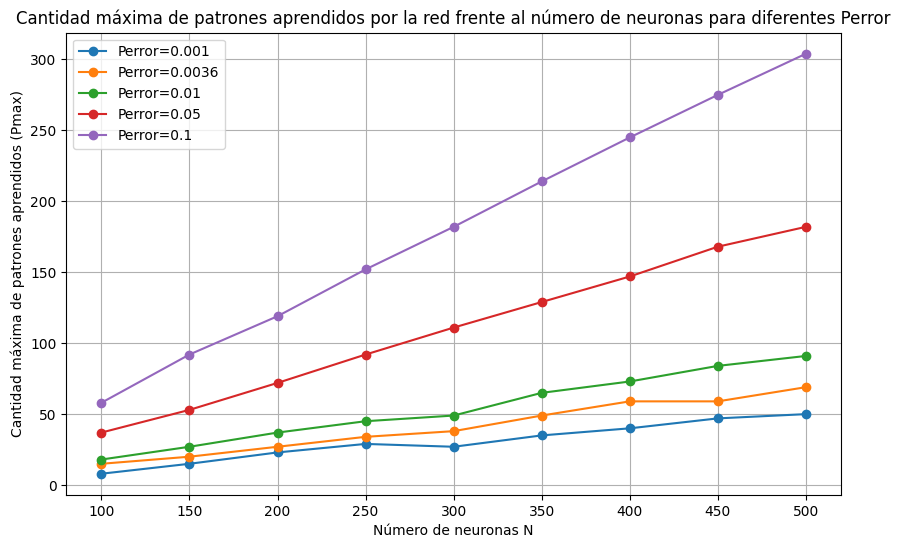

In [129]:
N = 500
Perrors = [0.0010,0.0036,0.0100,0.0500,0.1000]  
Pmax_dict = {Perror: [] for Perror in Perrors}

# Calculo Pmax para cada valor de Perror y N
for Perror in Perrors:
    for i in range(100, N+1, 50):
        Pmax_dict[Perror].append(capacity_by_error(Perror, i) * i)

x = np.arange(100, N + 1, 50)

plt.figure(figsize=(10, 6))  

# Grafico para cada Perror
for Perror in Perrors:
    plt.plot(x, Pmax_dict[Perror], label=f'Perror={Perror}', linestyle='-', marker='o')

plt.xlabel('Número de neuronas N')
plt.ylabel('Cantidad máxima de patrones aprendidos (Pmax)')
plt.title('Cantidad máxima de patrones aprendidos por la red frente al número de neuronas para diferentes Perror')
plt.legend()  
plt.grid(True)  
plt.show()


In [130]:
def generate_correlated_patterns_bernoulli(base_pattern, correlation, num_patterns):
    
    # Genera patrones correlacionados utilizando una distribución Bernoulli controlada por un vector de arranque.
    N = len(base_pattern)
    correlated_patterns = np.empty((N, num_patterns))
    
    for i in range(num_patterns):
        for j in range(N):
            prob = (1 + correlation) / 2 if base_pattern[j] == 1 else (1 - correlation) / 2
            correlated_patterns[j, i] = 1 if np.random.rand() < prob else -1
    
    return correlated_patterns

def capacity_by_error_correlated(P_error, N, correlation, max_iter=1000):
    # Calcula la capacidad máxima de la red de Hopfield para patrones correlacionados.
    
    hopfield_net = HopfieldNetwork(N)
    patterns_accumulated = np.empty((N, 0))
    error_neurons = 0
    iteration = 0
    
    # Genero patrón base aleatorio
    base_pattern = np.random.choice([-1, 1], size=(N,))
    
    while error_neurons < P_error and iteration < max_iter:
        # Genero un nuevo patrón correlacionado con la distribución Bernoulli
        correlated_pattern = generate_correlated_patterns_bernoulli(base_pattern, correlation, 1).reshape(N, 1)
        
        hopfield_net.train(correlated_pattern)
        patterns_accumulated = np.hstack((patterns_accumulated, correlated_pattern))
        
        evaluated_patterns = hopfield_net.evaluate_synchronous(patterns_accumulated)
        
        differences = evaluated_patterns - patterns_accumulated
        error_neurons = np.count_nonzero(differences) / (patterns_accumulated.shape[1] * N)
        
        iteration += 1
       
    capacity = (patterns_accumulated.shape[1] - 1) / N
    return capacity


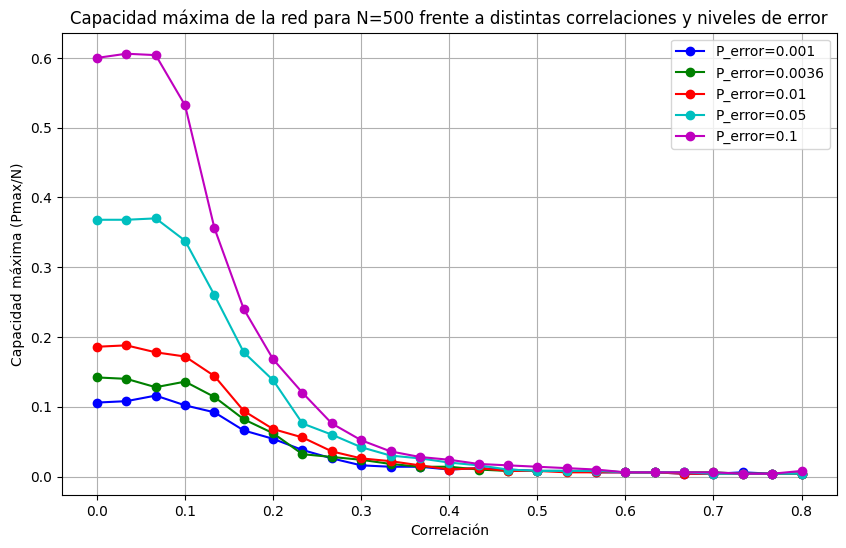

In [131]:
def plot_capacity_by_correlation(N, P_errors, correlations, max_iter=1000):
    
    #Genera un gráfico de la capacidad máxima de la red (Pmax) para distintos niveles de error (P_error) 
    #y diferentes correlaciones.
    
    
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']   
    
    plt.figure(figsize=(10, 6))  

    for idx, P_error in enumerate(P_errors):
        Pmax_values = []

        # Calculo capacidad para cada correlación dada
        for corr in correlations:
            capacities = capacity_by_error_correlated(P_error, N, corr, max_iter)
            Pmax_values.append(capacities)

        # Grafico para este P_error
        color = colors[idx % len(colors)]
        style = '-'
        plt.plot(correlations, Pmax_values, marker='o', linestyle=style, color=color, 
                 label=f'P_error={P_error}')
    
    
    plt.xlabel('Correlación')
    plt.ylabel('Capacidad máxima (Pmax/N)')
    plt.title(f'Capacidad máxima de la red para N={N} frente a distintas correlaciones y niveles de error')
    plt.legend()  
    plt.grid(True)  
    plt.show()  


N = 500  
P_errors = [0.0010,0.0036,0.0100,0.0500,0.1000]  # Diferentes valores de P_error
correlations = np.linspace(0, 0.8, 25)  # Correlaciones desde 0 a 1

plot_capacity_by_correlation(N, P_errors, correlations, max_iter=1000)